# Imports

In [2]:
# importing different packages
import pandas as pd
import pickle
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from shapely.geometry import Point
import math

In [7]:
# ----------------------------
# Helpers
# ----------------------------
def _numeric_cols(df: pd.DataFrame, exclude=("zip_code",)) -> list[str]:
    cols = df.select_dtypes(include="number").columns.tolist()
    return [c for c in cols if c not in set(exclude)]

def _auto_log_cols(df: pd.DataFrame, cols: list[str], skew_thresh: float = 1.25) -> list[str]:
    """
    Choose columns that are:
      - nonnegative (so log1p is safe)
      - meaningfully skewed to the right
    """
    log_cols = []
    for c in cols:
        s = df[c].dropna()
        if len(s) < 30:
            continue
        if (s >= 0).all():
            sk = float(s.skew())
            if sk > skew_thresh:
                log_cols.append(c)
    return log_cols

def _pretty_title(s: str) -> str:
    return s.replace("_", " ").strip()

# ----------------------------
# 1) Missingness
# ----------------------------
def plot_missingness(df: pd.DataFrame, top_n: int = 40) -> None:
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss.head(top_n)

    plt.figure(figsize=(10, max(3, 0.25 * len(miss))))
    plt.barh(miss.index[::-1], miss.values[::-1])
    plt.xlabel("Missing share")
    plt.title("Missingness by column (top)")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 2) Histograms (optionally log1p)
# ----------------------------
def plot_hist_grid(
    df: pd.DataFrame,
    cols: list[str] | None = None,
    max_plots: int = 20,
    bins: int = 40,
    use_auto_log: bool = True,
    exclude=("zip_code", "lat", "lon"),
) -> None:
    if cols is None:
        cols = _numeric_cols(df, exclude=exclude)
    cols = [c for c in cols if c in df.columns]
    cols = cols[:max_plots]

    log_cols = _auto_log_cols(df, cols) if use_auto_log else []

    n = len(cols)
    if n == 0:
        print("No columns to plot.")
        return

    ncols = 4
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(4 * ncols, 3.2 * nrows))

    for i, c in enumerate(cols, start=1):
        ax = fig.add_subplot(nrows, ncols, i)
        s = df[c].dropna()

        title = _pretty_title(c)
        if c in log_cols:
            s = np.log1p(s)
            title += " (log1p)"

        ax.hist(s, bins=bins)
        ax.set_title(title)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 3) Correlation heatmap
# ----------------------------
def plot_corr_heatmap(
    df: pd.DataFrame,
    cols: list[str] | None = None,
    method: str = "pearson",
    exclude=("zip_code",),
) -> None:
    if cols is None:
        cols = _numeric_cols(df, exclude=exclude)
    cols = [c for c in cols if c in df.columns]

    corr = df[cols].corr(method=method, numeric_only=True)

    plt.figure(figsize=(0.45 * len(cols) + 6, 0.45 * len(cols) + 6))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar(label=f"{method} correlation")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 4) Targeted scatter plots (good “what’s in here?” views)
# ----------------------------
def scatter(df: pd.DataFrame, x: str, y: str, log1p_x: bool = False, log1p_y: bool = False) -> None:
    d = df[[x, y]].dropna()
    if len(d) == 0:
        print(f"No non-null rows for {x} vs {y}")
        return

    X = np.log1p(d[x].to_numpy()) if log1p_x else d[x].to_numpy()
    Y = np.log1p(d[y].to_numpy()) if log1p_y else d[y].to_numpy()

    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(X, Y, s=12, alpha=0.6)
    plt.xlabel(_pretty_title(x) + (" (log1p)" if log1p_x else ""))
    plt.ylabel(_pretty_title(y) + (" (log1p)" if log1p_y else ""))
    plt.title(f"{_pretty_title(y)} vs {_pretty_title(x)}")
    plt.tight_layout()
    plt.show()

def run_core_scatter_set(df: pd.DataFrame) -> None:
    # Common “does this line up?” pairs for your columns
    pairs = [
        ("median_household_income", "PV_system_size_DC"),
        ("median_household_income", "zev_count"),
        ("total_population", "zev_count"),
        ("total_chargers", "zev_count"),
        ("PV_system_size_DC", "ghi_mean_kwh_m2_day_2024"),
        ("wind_capacity_mw", "wind_ws50m_mean_2024"),
        ("storage_capacity_mw", "plant_capacity_mw"),
        ("poverty_rate", "PV_system_size_DC"),
        ("pct_bachelors_plus", "PV_system_size_DC"),
    ]

    for x, y in pairs:
        if x in df.columns and y in df.columns:
            # For heavy-tailed stuff like counts/capacities, log1p often helps
            logx = x in {"total_population", "median_household_income", "total_chargers", "zev_count"}
            logy = y in {"PV_system_size_DC", "zev_count", "total_chargers", "wind_capacity_mw", "storage_capacity_mw", "plant_capacity_mw"}
            scatter(df, x, y, log1p_x=logx, log1p_y=logy)

# ----------------------------
# 5) Quick lat/lon “map” scatter
# ----------------------------
def plot_geo_scatter(
    df: pd.DataFrame,
    value_col: str,
    size_scale: float = 30.0,
    log1p_size: bool = True,
    alpha: float = 0.6,
) -> None:
    needed = {"lat", "lon", value_col}
    if not needed.issubset(df.columns):
        print(f"Need columns {needed} to plot.")
        return

    d = df[["lat", "lon", value_col]].dropna()
    if len(d) == 0:
        print(f"No non-null rows for lat/lon/{value_col}")
        return

    v = d[value_col].to_numpy()
    s = np.log1p(v) if log1p_size else v
    s = np.clip(s, 0, np.nanpercentile(s, 99))  # reduce extreme marker blowups
    sizes = (s + 1e-6) * size_scale

    plt.figure(figsize=(7.2, 5.2))
    plt.scatter(d["lon"], d["lat"], s=sizes, alpha=alpha)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"lat/lon scatter sized by {_pretty_title(value_col)}" + (" (log1p size)" if log1p_size else ""))
    plt.tight_layout()
    plt.show()

import geopandas as gpd

# ----------------------------
# 5b) Choropleth by ZIP (California)
# ----------------------------
def _ensure_zip_str(s: pd.Series) -> pd.Series:
    return s.astype(str).str.zfill(5)

def load_ca_zctas(zip_shapefile: str, states_geojson: str | None = None) -> gpd.GeoDataFrame:
    """
    Load national ZCTA polygons and clip to California.
    Returns GeoDataFrame with a clean ZIP key column 'ZCTA5CE20' (zero-padded).
    """
    if states_geojson is None:
        states_geojson = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"

    zctas = gpd.read_file(zip_shapefile)
    states = gpd.read_file(states_geojson)
    ca = states[states["name"] == "California"].copy()
    if ca.empty:
        raise ValueError("California not found in the states GeoJSON (expected states['name'] == 'California').")

    # If shapefile CRS missing, set a common TIGER default (often EPSG:4269)
    if zctas.crs is None:
        zctas = zctas.set_crs("EPSG:4269")

    # Match CRS for clipping
    if ca.crs != zctas.crs:
        ca = ca.to_crs(zctas.crs)

    if "ZCTA5CE20" not in zctas.columns:
        raise ValueError("Expected ZCTA shapefile column 'ZCTA5CE20' not found.")

    zctas["ZCTA5CE20"] = zctas["ZCTA5CE20"].astype(str).str.zfill(5)

    # Clip (more robust than within)
    zctas_ca = gpd.clip(zctas, ca.geometry.iloc[0])
    return zctas_ca

def plot_zip_choropleth(
    df: pd.DataFrame,
    value_col: str,
    zctas_ca: gpd.GeoDataFrame,
    how: str = "sum",              # 'sum' | 'mean' | 'count' | 'median'
    log1p_color: bool = True,
    cmap: str = "viridis",
    missing_color: str = "lightgray",
    figsize=(12, 12),
) -> None:
    """
    Choropleth of a metric aggregated to ZIP codes over California ZCTAs.

    - df must contain 'zip_code' and value_col (unless how='count', then value_col is ignored)
    - zctas_ca should come from load_ca_zctas()
    """
    if "zip_code" not in df.columns:
        print("Need 'zip_code' column for choropleth.")
        return

    if how != "count" and value_col not in df.columns:
        print(f"Need '{value_col}' in df for choropleth.")
        return

    d = df.copy()
    d["zip_code"] = _ensure_zip_str(d["zip_code"])

    # Aggregate
    if how == "count":
        metric = d.groupby("zip_code").size().reset_index(name=value_col)
    else:
        agg_map = {"sum": "sum", "mean": "mean", "median": "median"}
        if how not in agg_map:
            raise ValueError("how must be one of: 'sum', 'mean', 'median', 'count'")
        metric = d.groupby("zip_code")[value_col].agg(agg_map[how]).reset_index()

    # Merge with polygons
    g = zctas_ca.merge(metric, left_on="ZCTA5CE20", right_on="zip_code", how="left")
    g[value_col] = g[value_col].fillna(0)

    plot_col = value_col
    title = f"California ZIP choropleth: {_pretty_title(value_col)} ({how})"

    if log1p_color:
        plot_col = f"{value_col}__log1p"
        g[plot_col] = np.log1p(g[value_col].clip(lower=0))
        title += " (log1p)"

    fig, ax = plt.subplots(figsize=figsize)

    # Draw zero/missing first so it’s clearly visible
    g[g[value_col] == 0].plot(ax=ax, color=missing_color, edgecolor="gray", linewidth=0.2)

    # Draw nonzero values with colormap
    nonzero = g[g[value_col] > 0]
    if len(nonzero) > 0:
        nonzero.plot(
            ax=ax,
            column=plot_col,
            cmap=cmap,
            legend=True,
            edgecolor="gray",
            linewidth=0.2,
            alpha=0.9,
            legend_kwds={"label": title, "orientation": "horizontal"},
        )

    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# ----------------------------
# One-call “give me the overview”
# ----------------------------
def run_eda_overview(df: pd.DataFrame, zctas_ca: "gpd.GeoDataFrame | None" = None) -> None:
    plot_missingness(df)

    preferred = [
        "PV_system_size_DC",
        "total_chargers",
        "zev_count",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
        "median_household_income",
        "poverty_rate",
        "pct_bachelors_plus",
        "pct_black",
        "pct_hispanic",
        "pct_asian",
        "median_housing_value",
        "total_population",
        "ghi_mean_kwh_m2_day_2024",
        "t2m_mean_c_2023",
        "cdd65_2023",
        "hdd65_2023",
        "wind_ws50m_mean_2024",
        "overlap_share_of_zip",
    ]
    preferred = [c for c in preferred if c in df.columns]
    plot_hist_grid(df, cols=preferred, max_plots=20, use_auto_log=True)

    plot_corr_heatmap(df)
    run_core_scatter_set(df)

    # ---- NEW: ZIP choropleths (California) ----
    if zctas_ca is not None and "zip_code" in df.columns:
        # pick a few good "map metrics" that exist in the df
        map_vars = ["PV_system_size_DC", "total_chargers", "zev_count", "wind_capacity_mw", "storage_capacity_mw"]
        map_vars = [c for c in map_vars if c in df.columns]

        for vc in map_vars[:4]:  # limit to avoid spamming plots
            plot_zip_choropleth(
                df,
                value_col=vc,
                zctas_ca=zctas_ca,
                how="sum",          # usually sum for capacities/counts
                log1p_color=True,
                cmap="viridis",
            )

        # occurrences map
        plot_zip_choropleth(
            df,
            value_col="occurrences",
            zctas_ca=zctas_ca,
            how="count",
            log1p_color=True,
            cmap="viridis",
        )

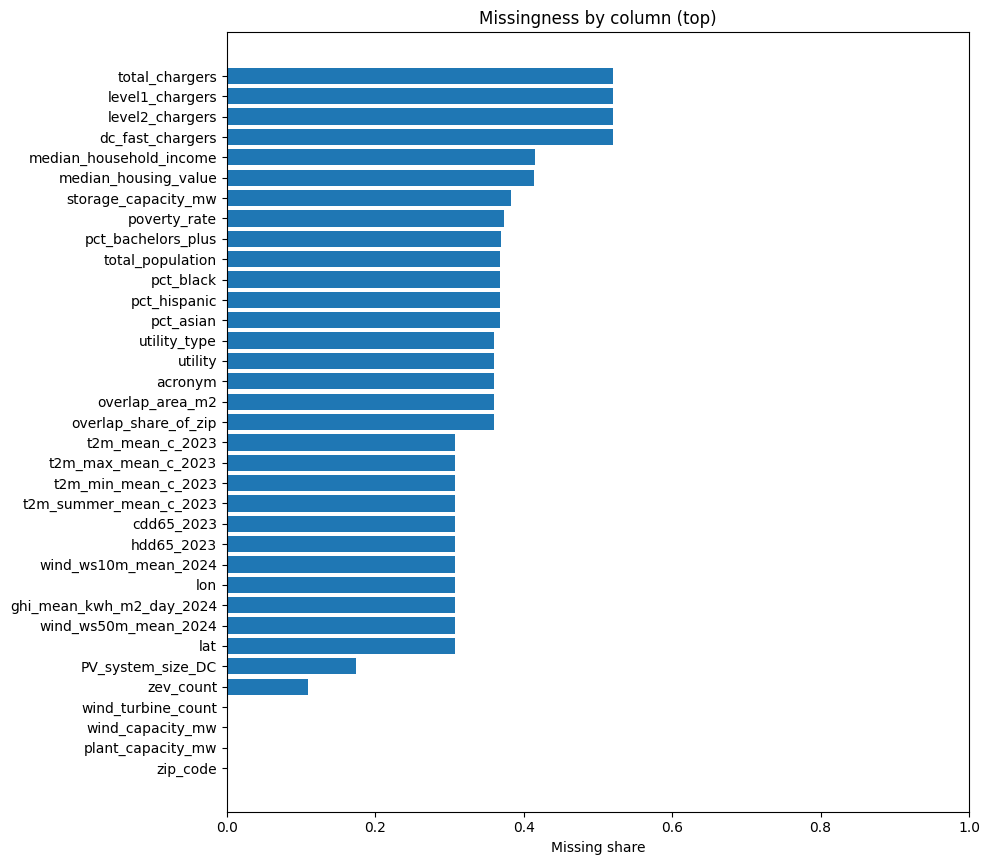

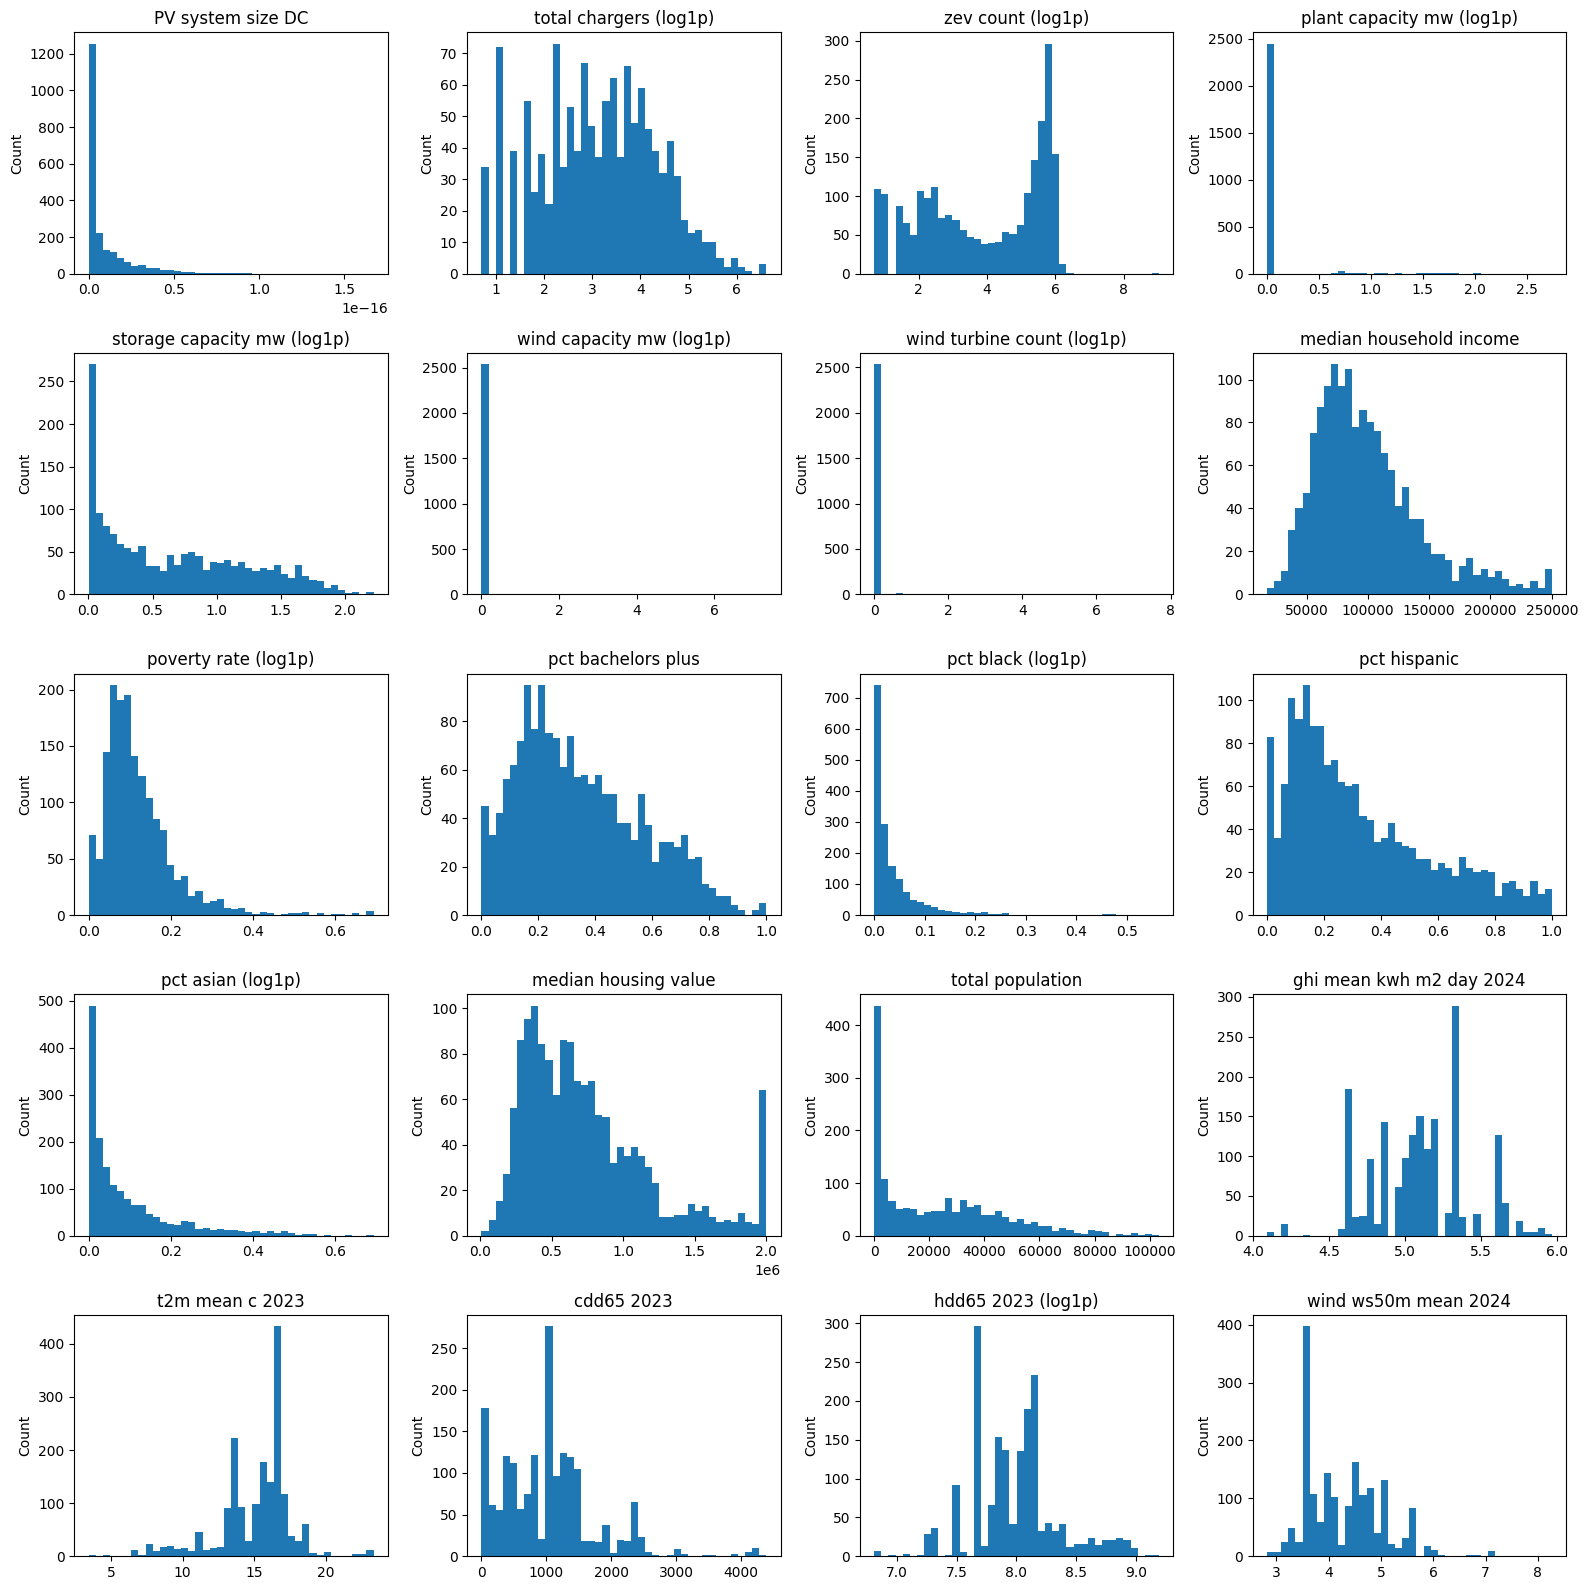

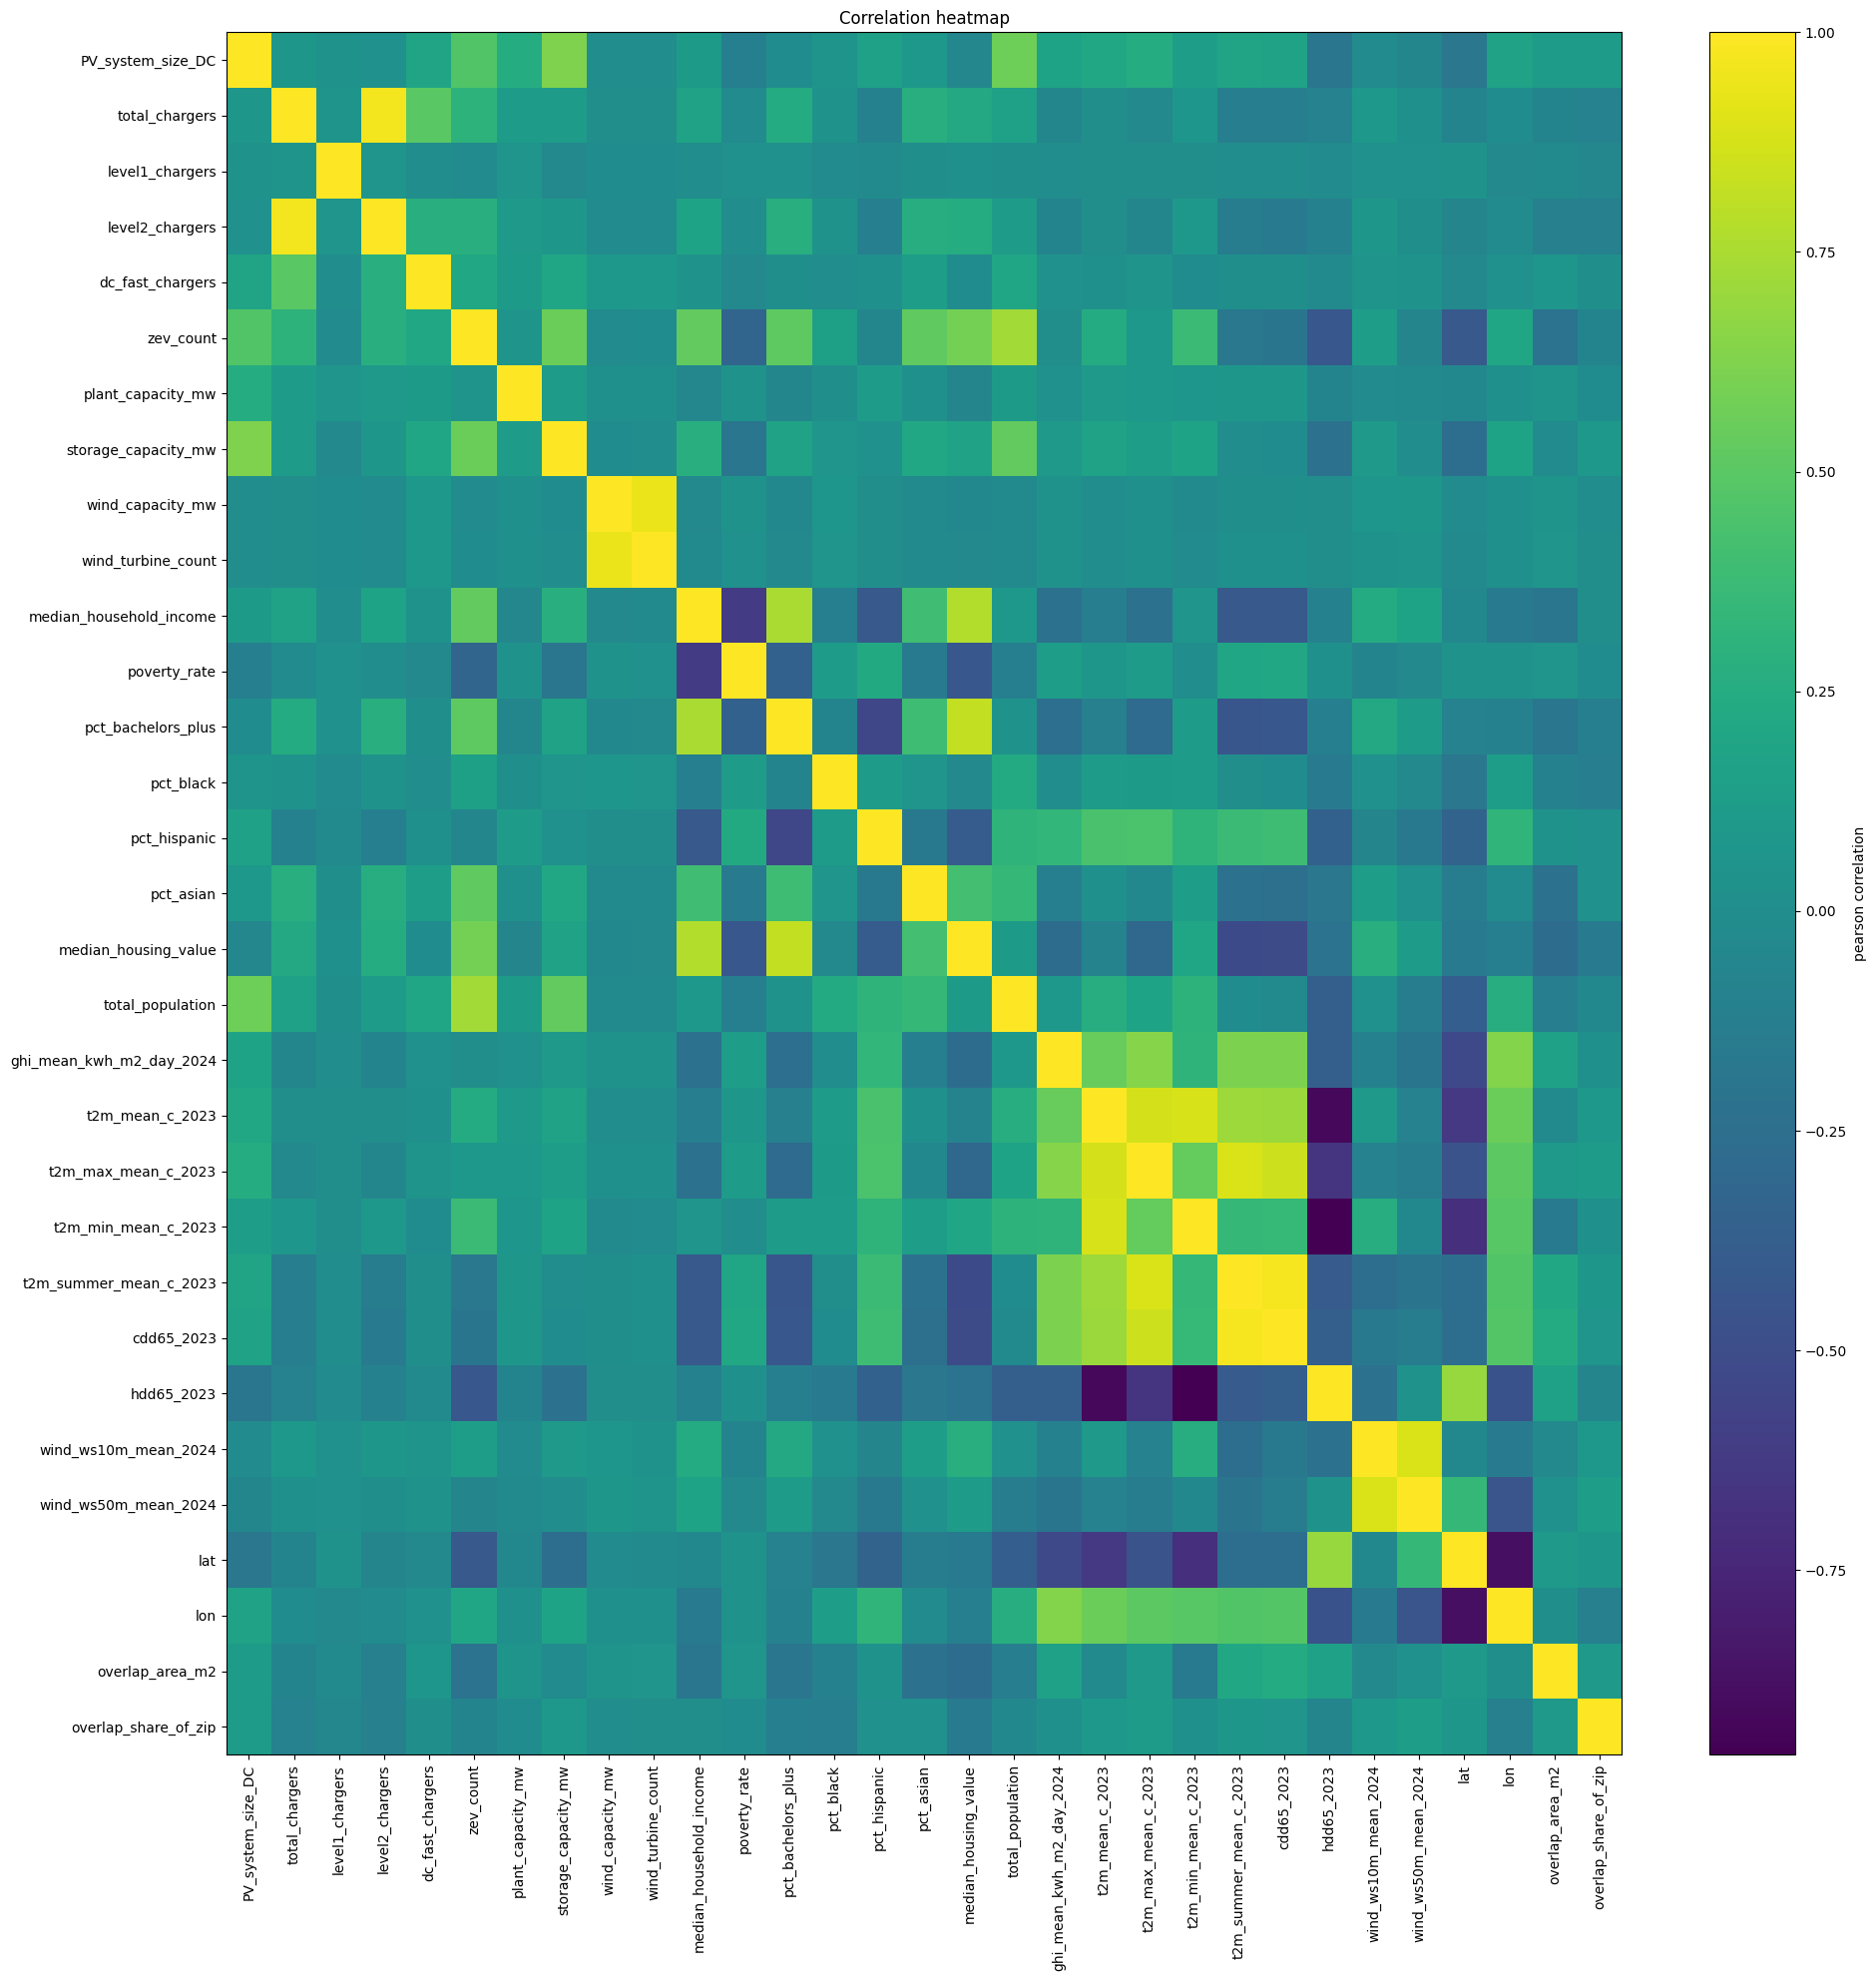

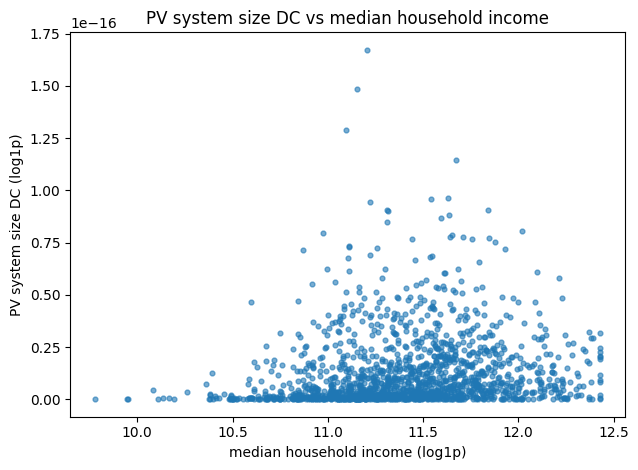

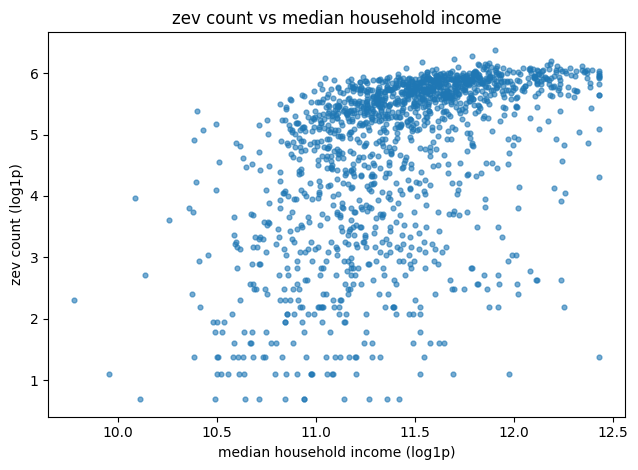

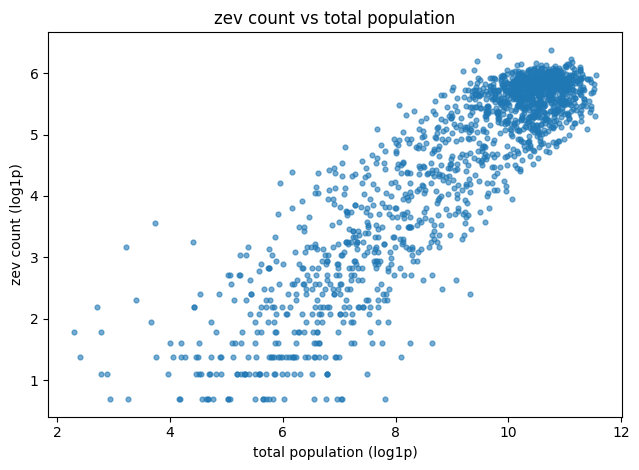

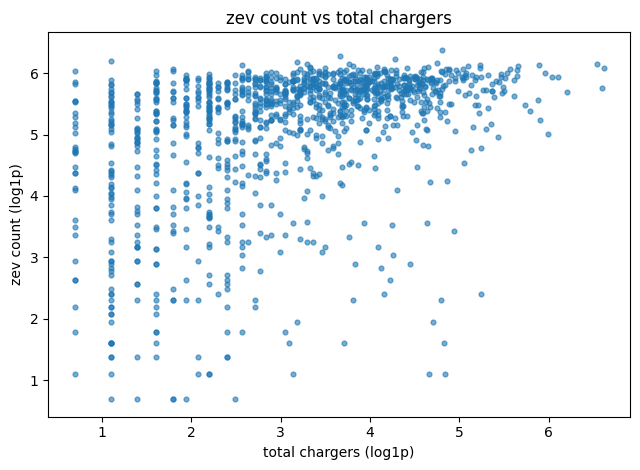

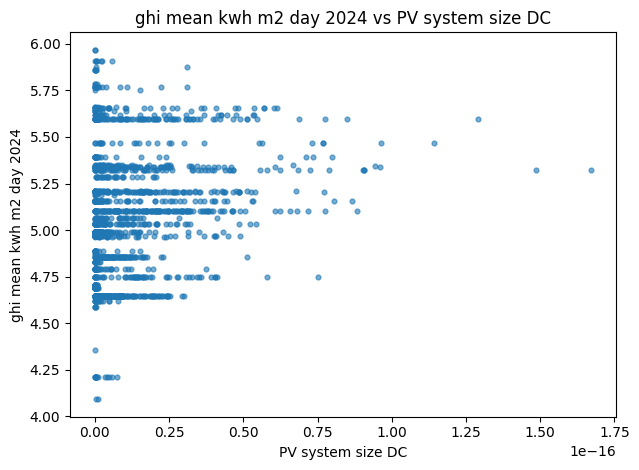

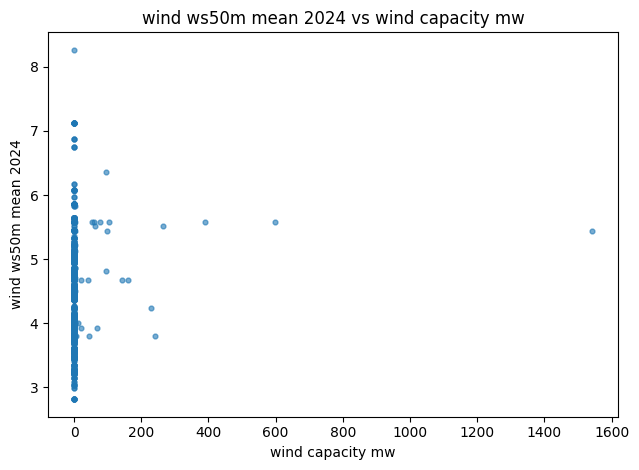

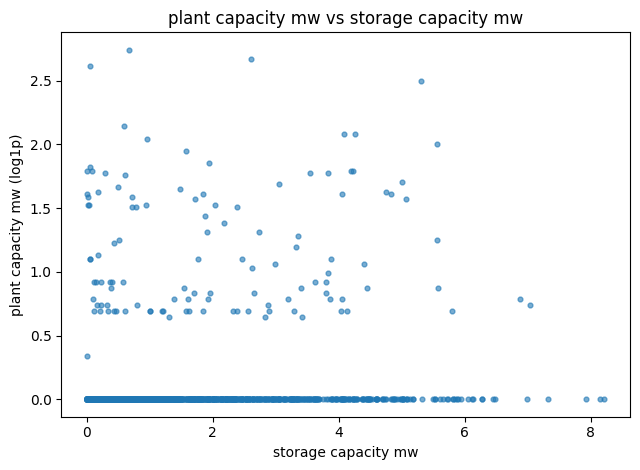

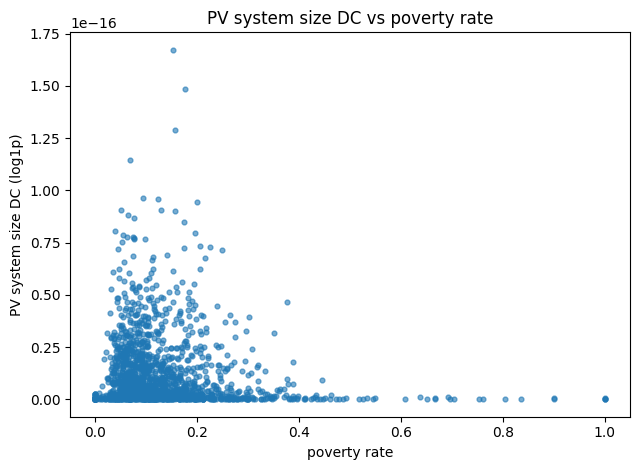

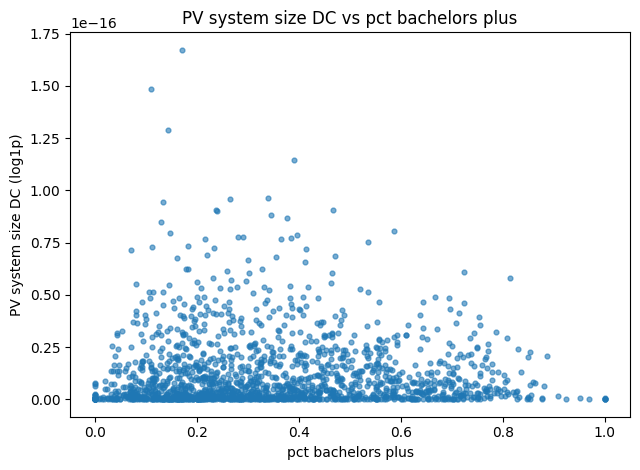

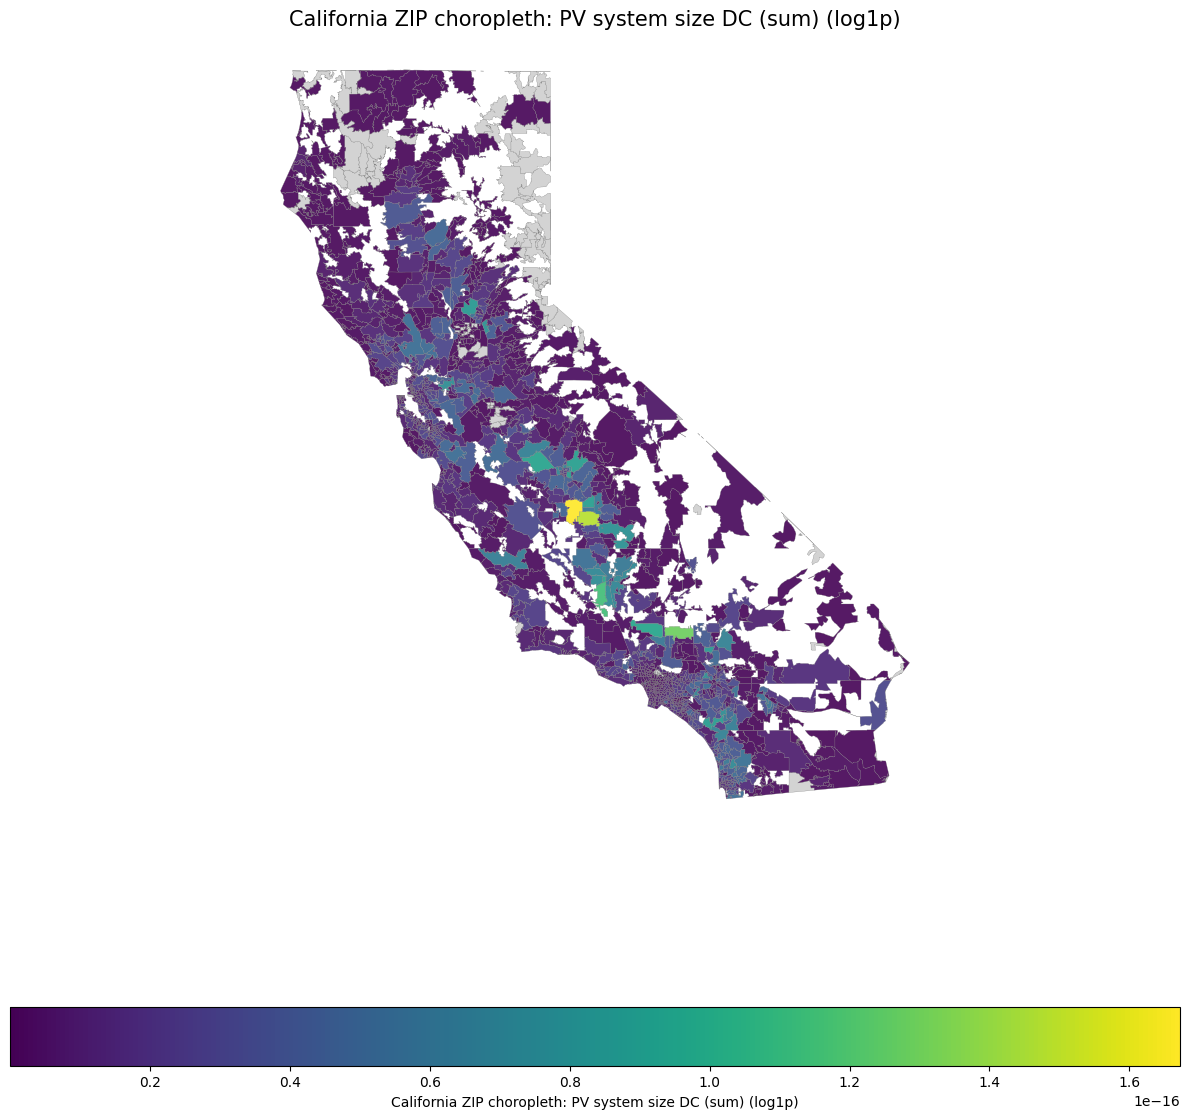

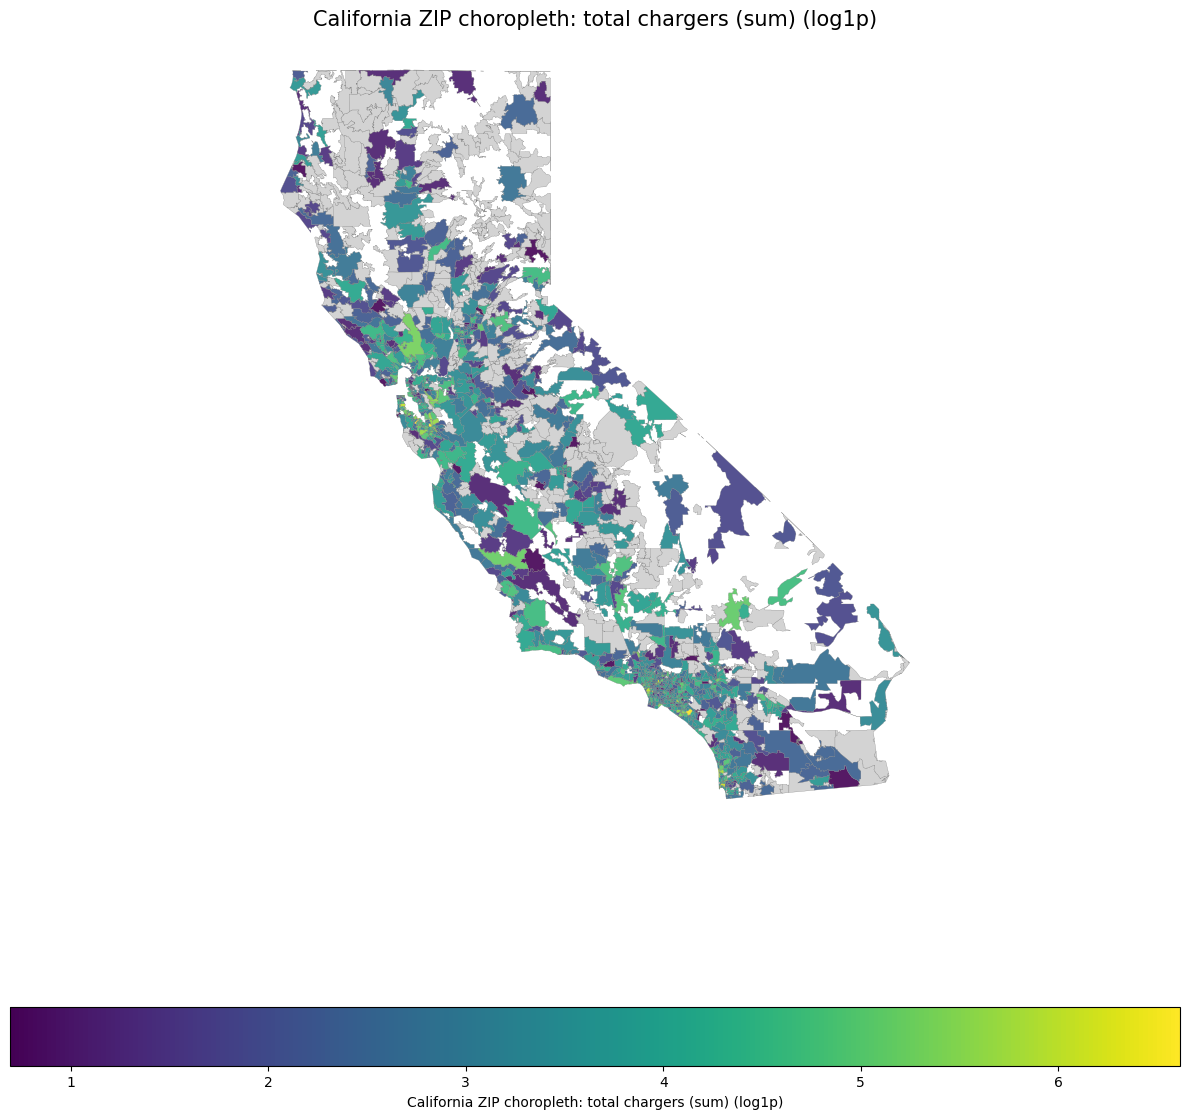

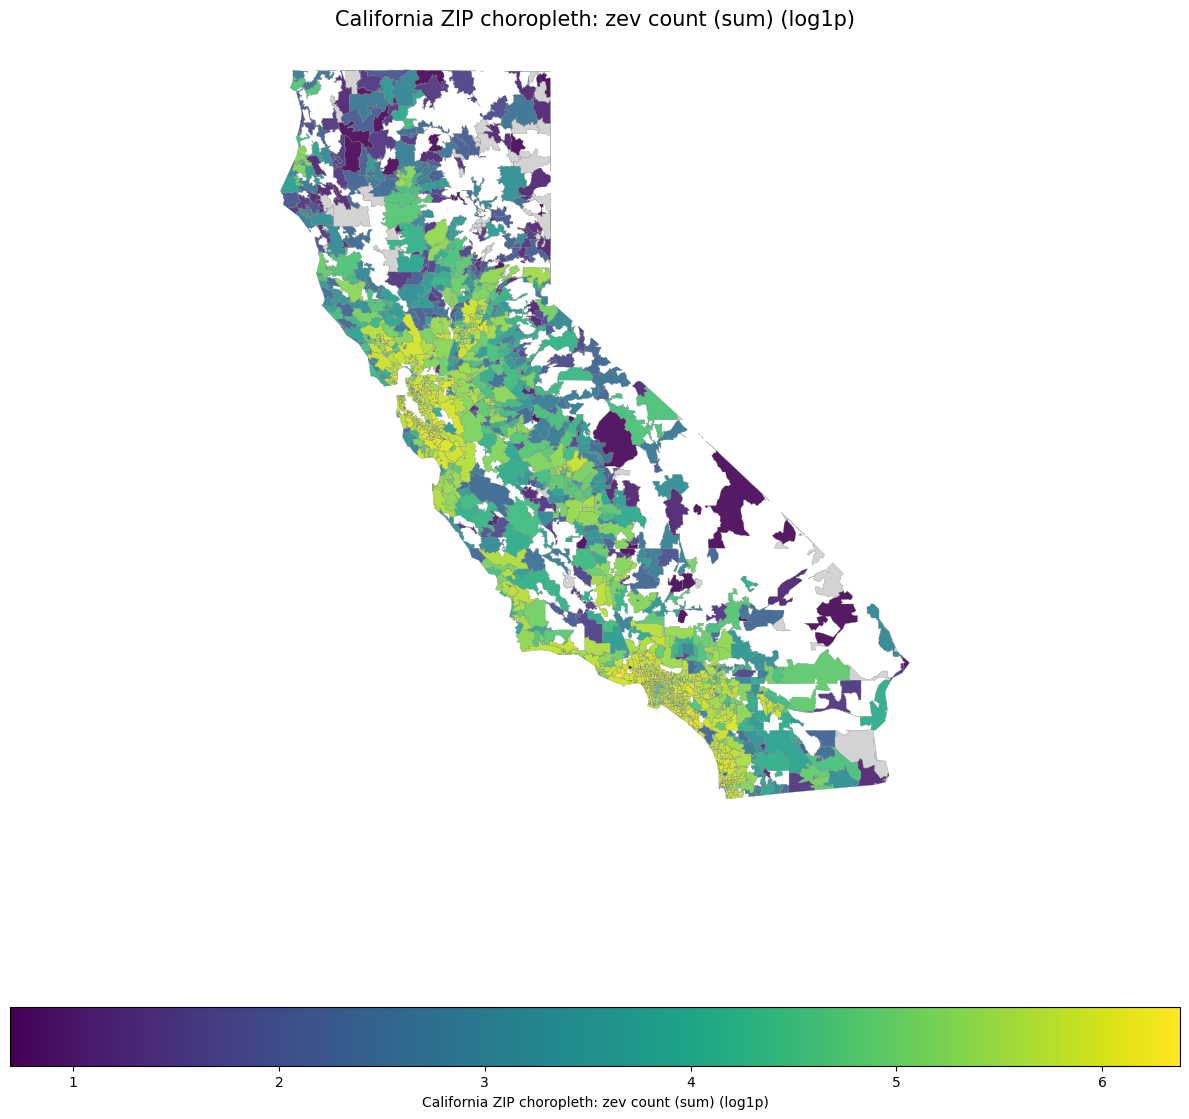

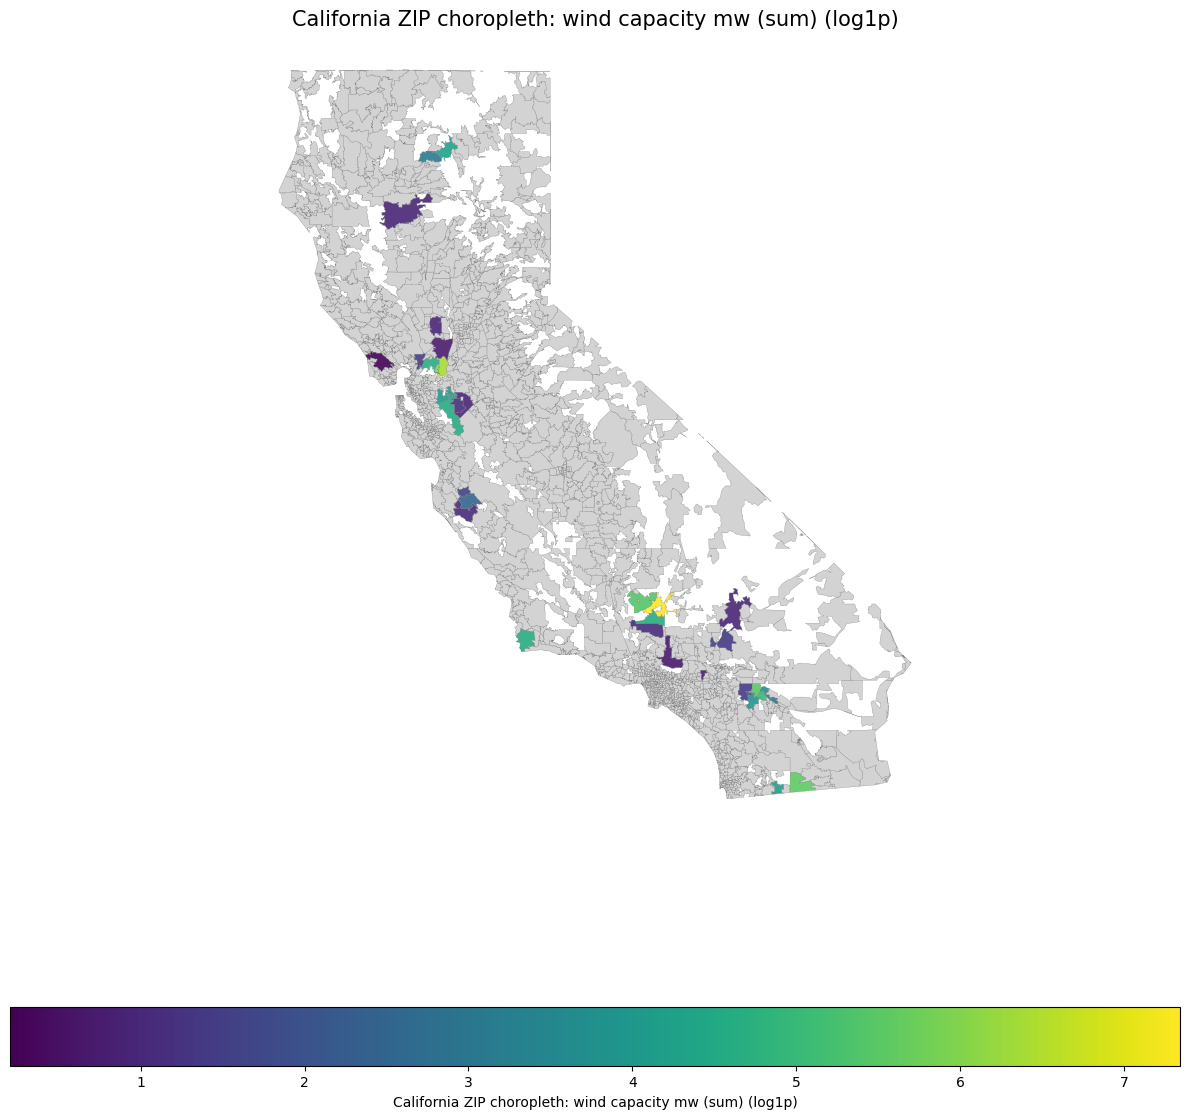

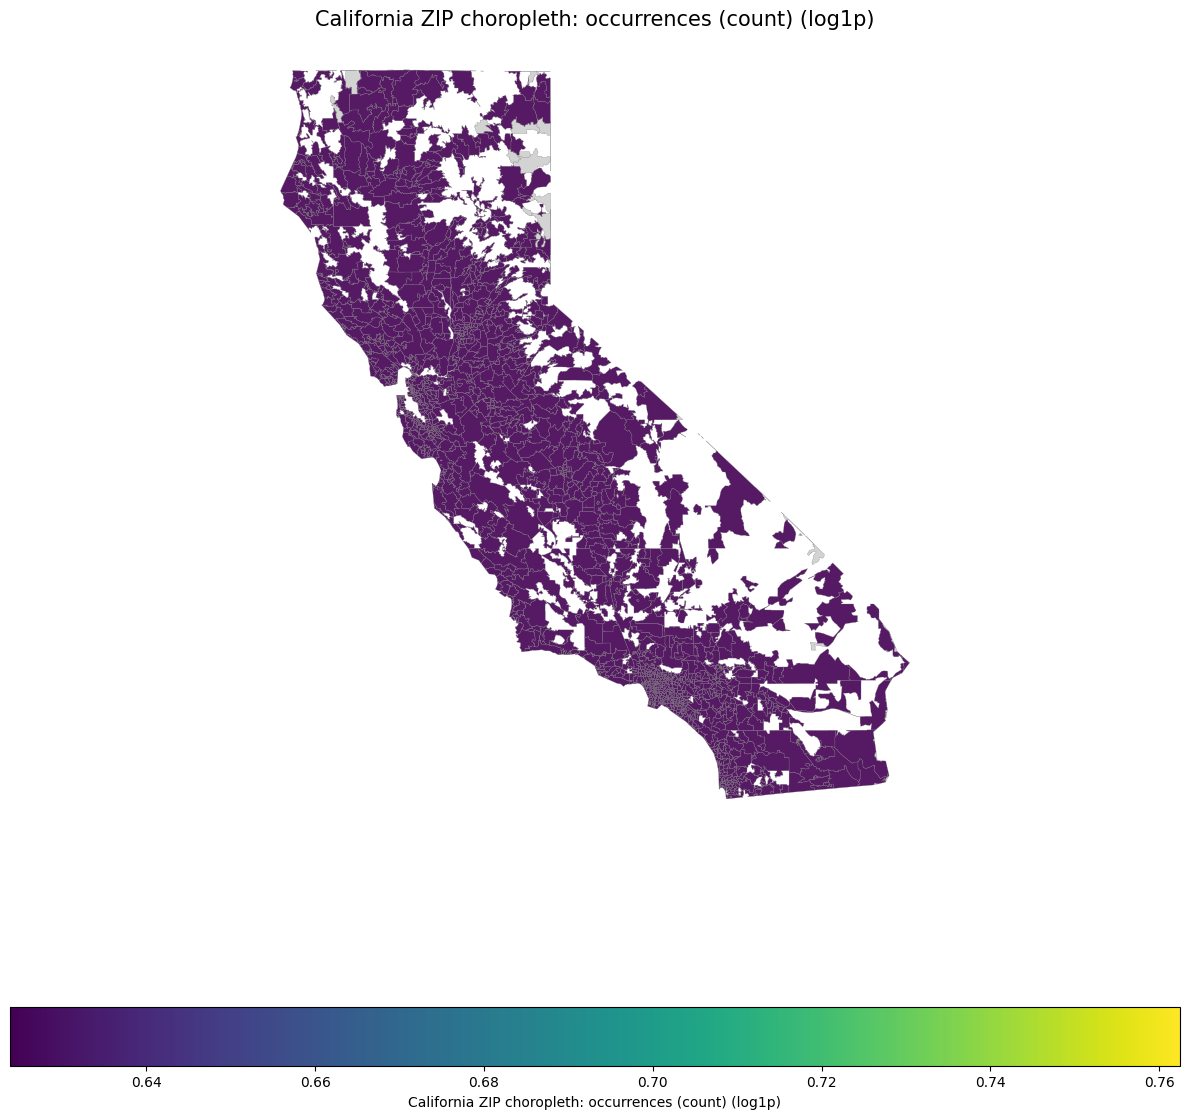

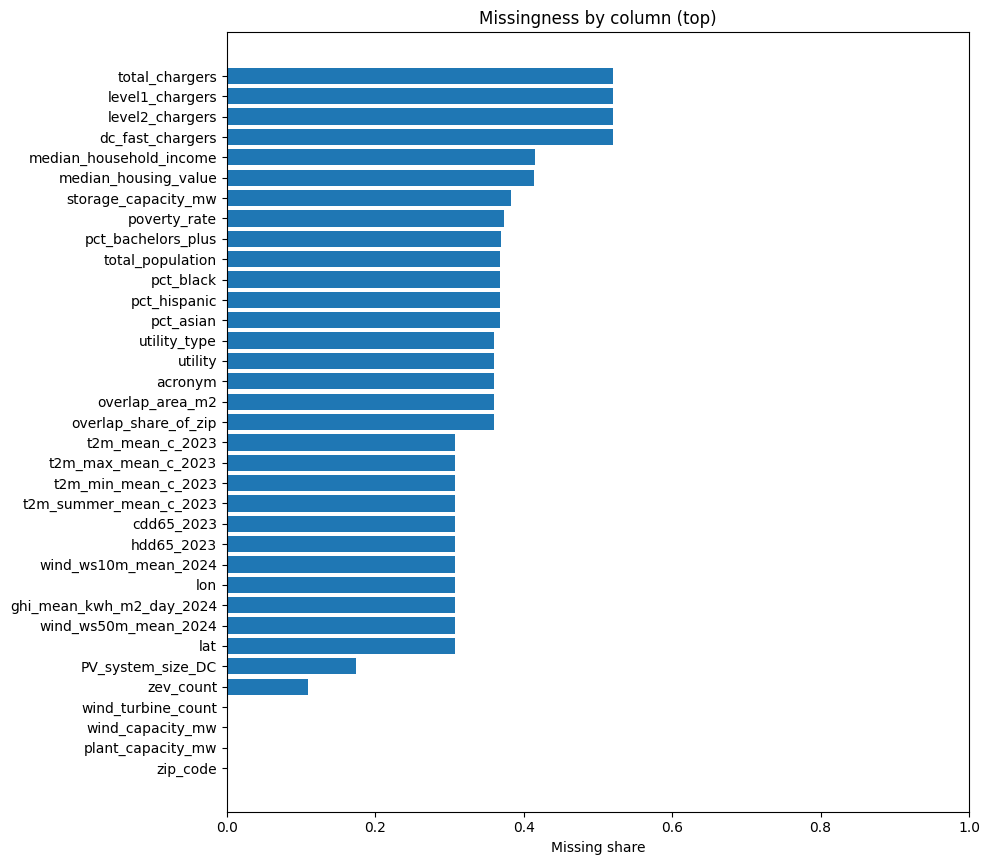

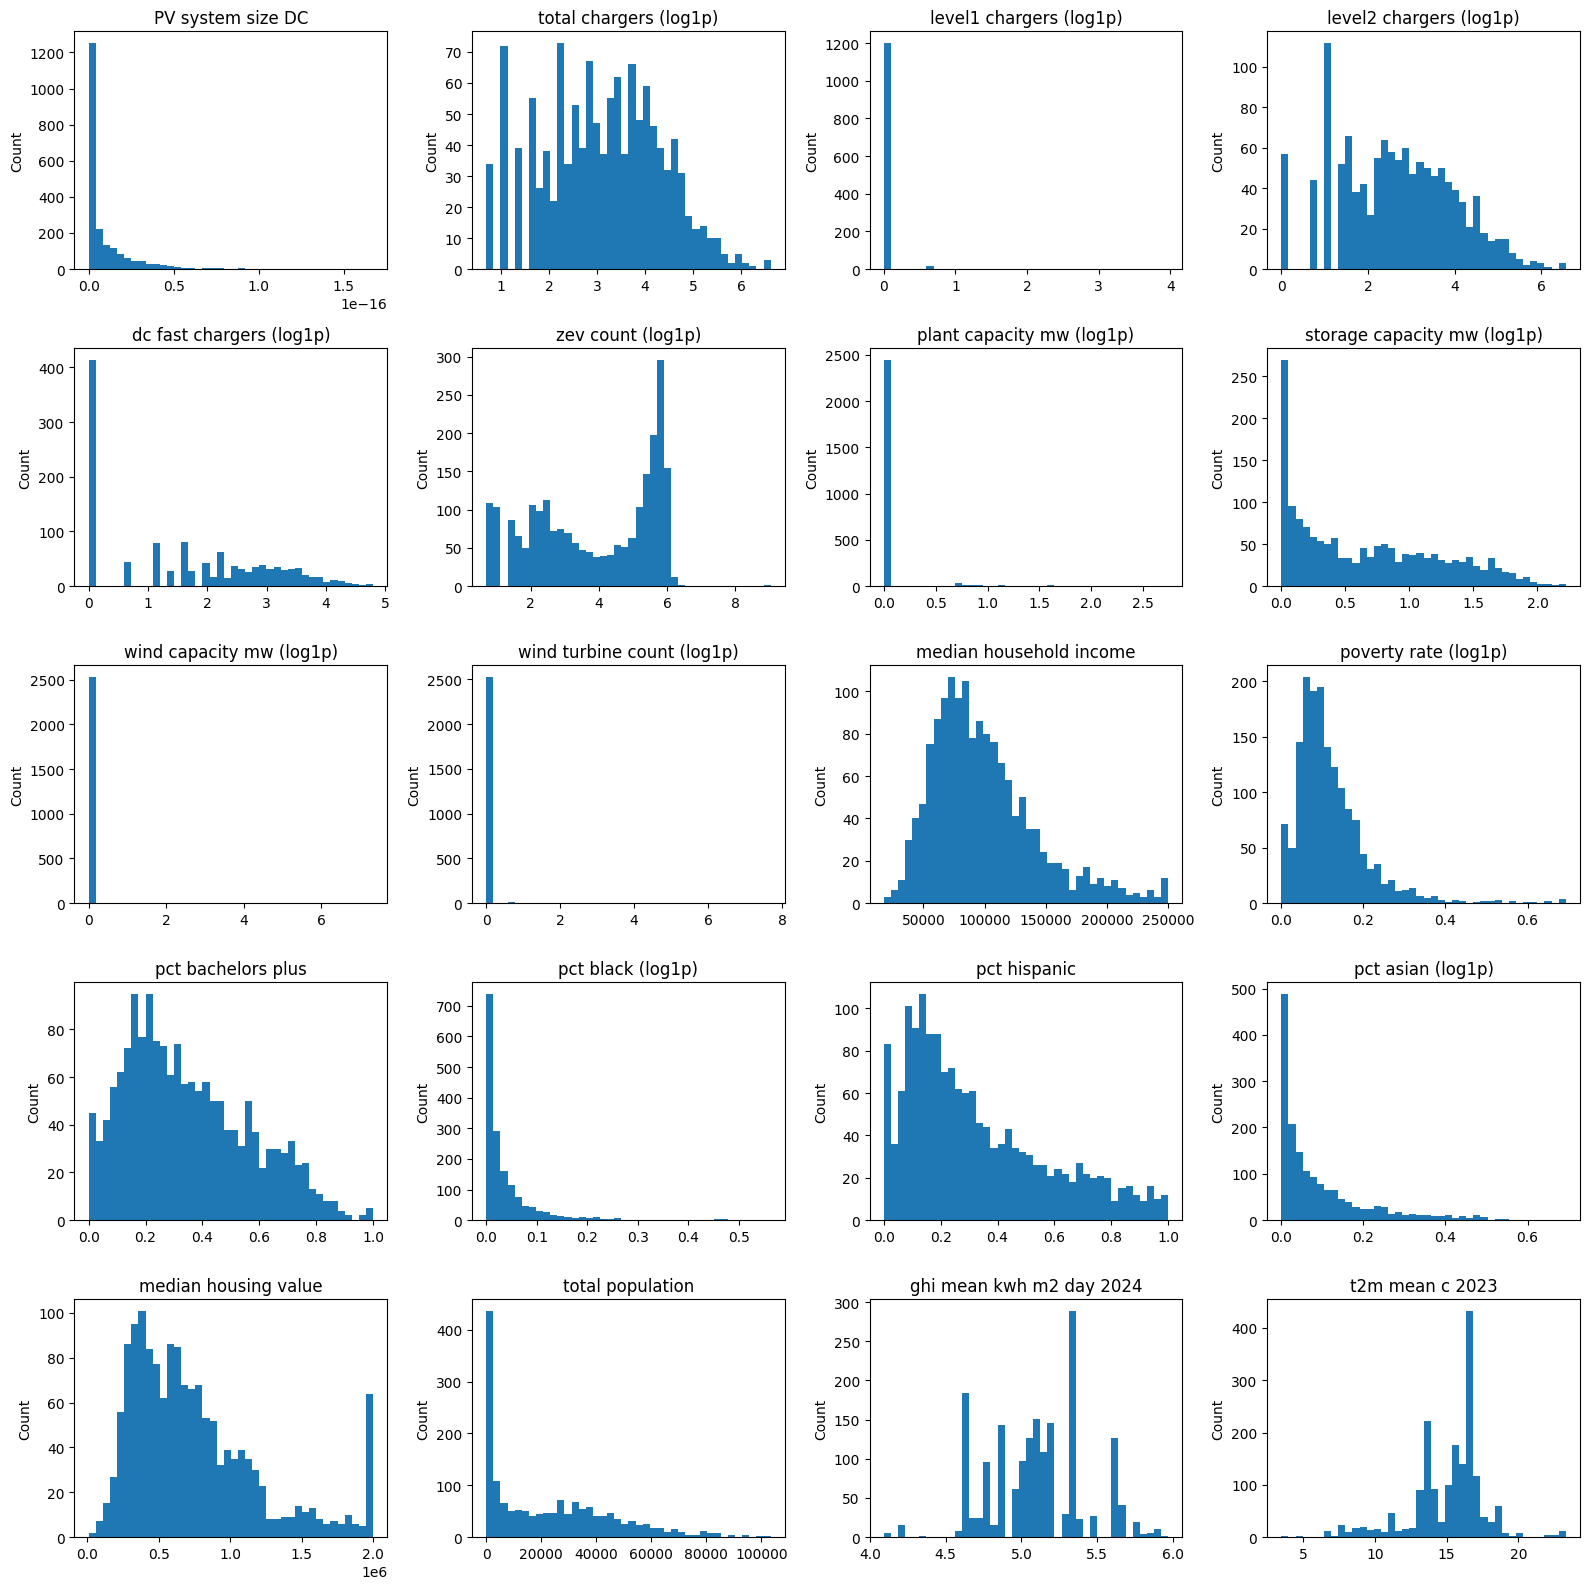

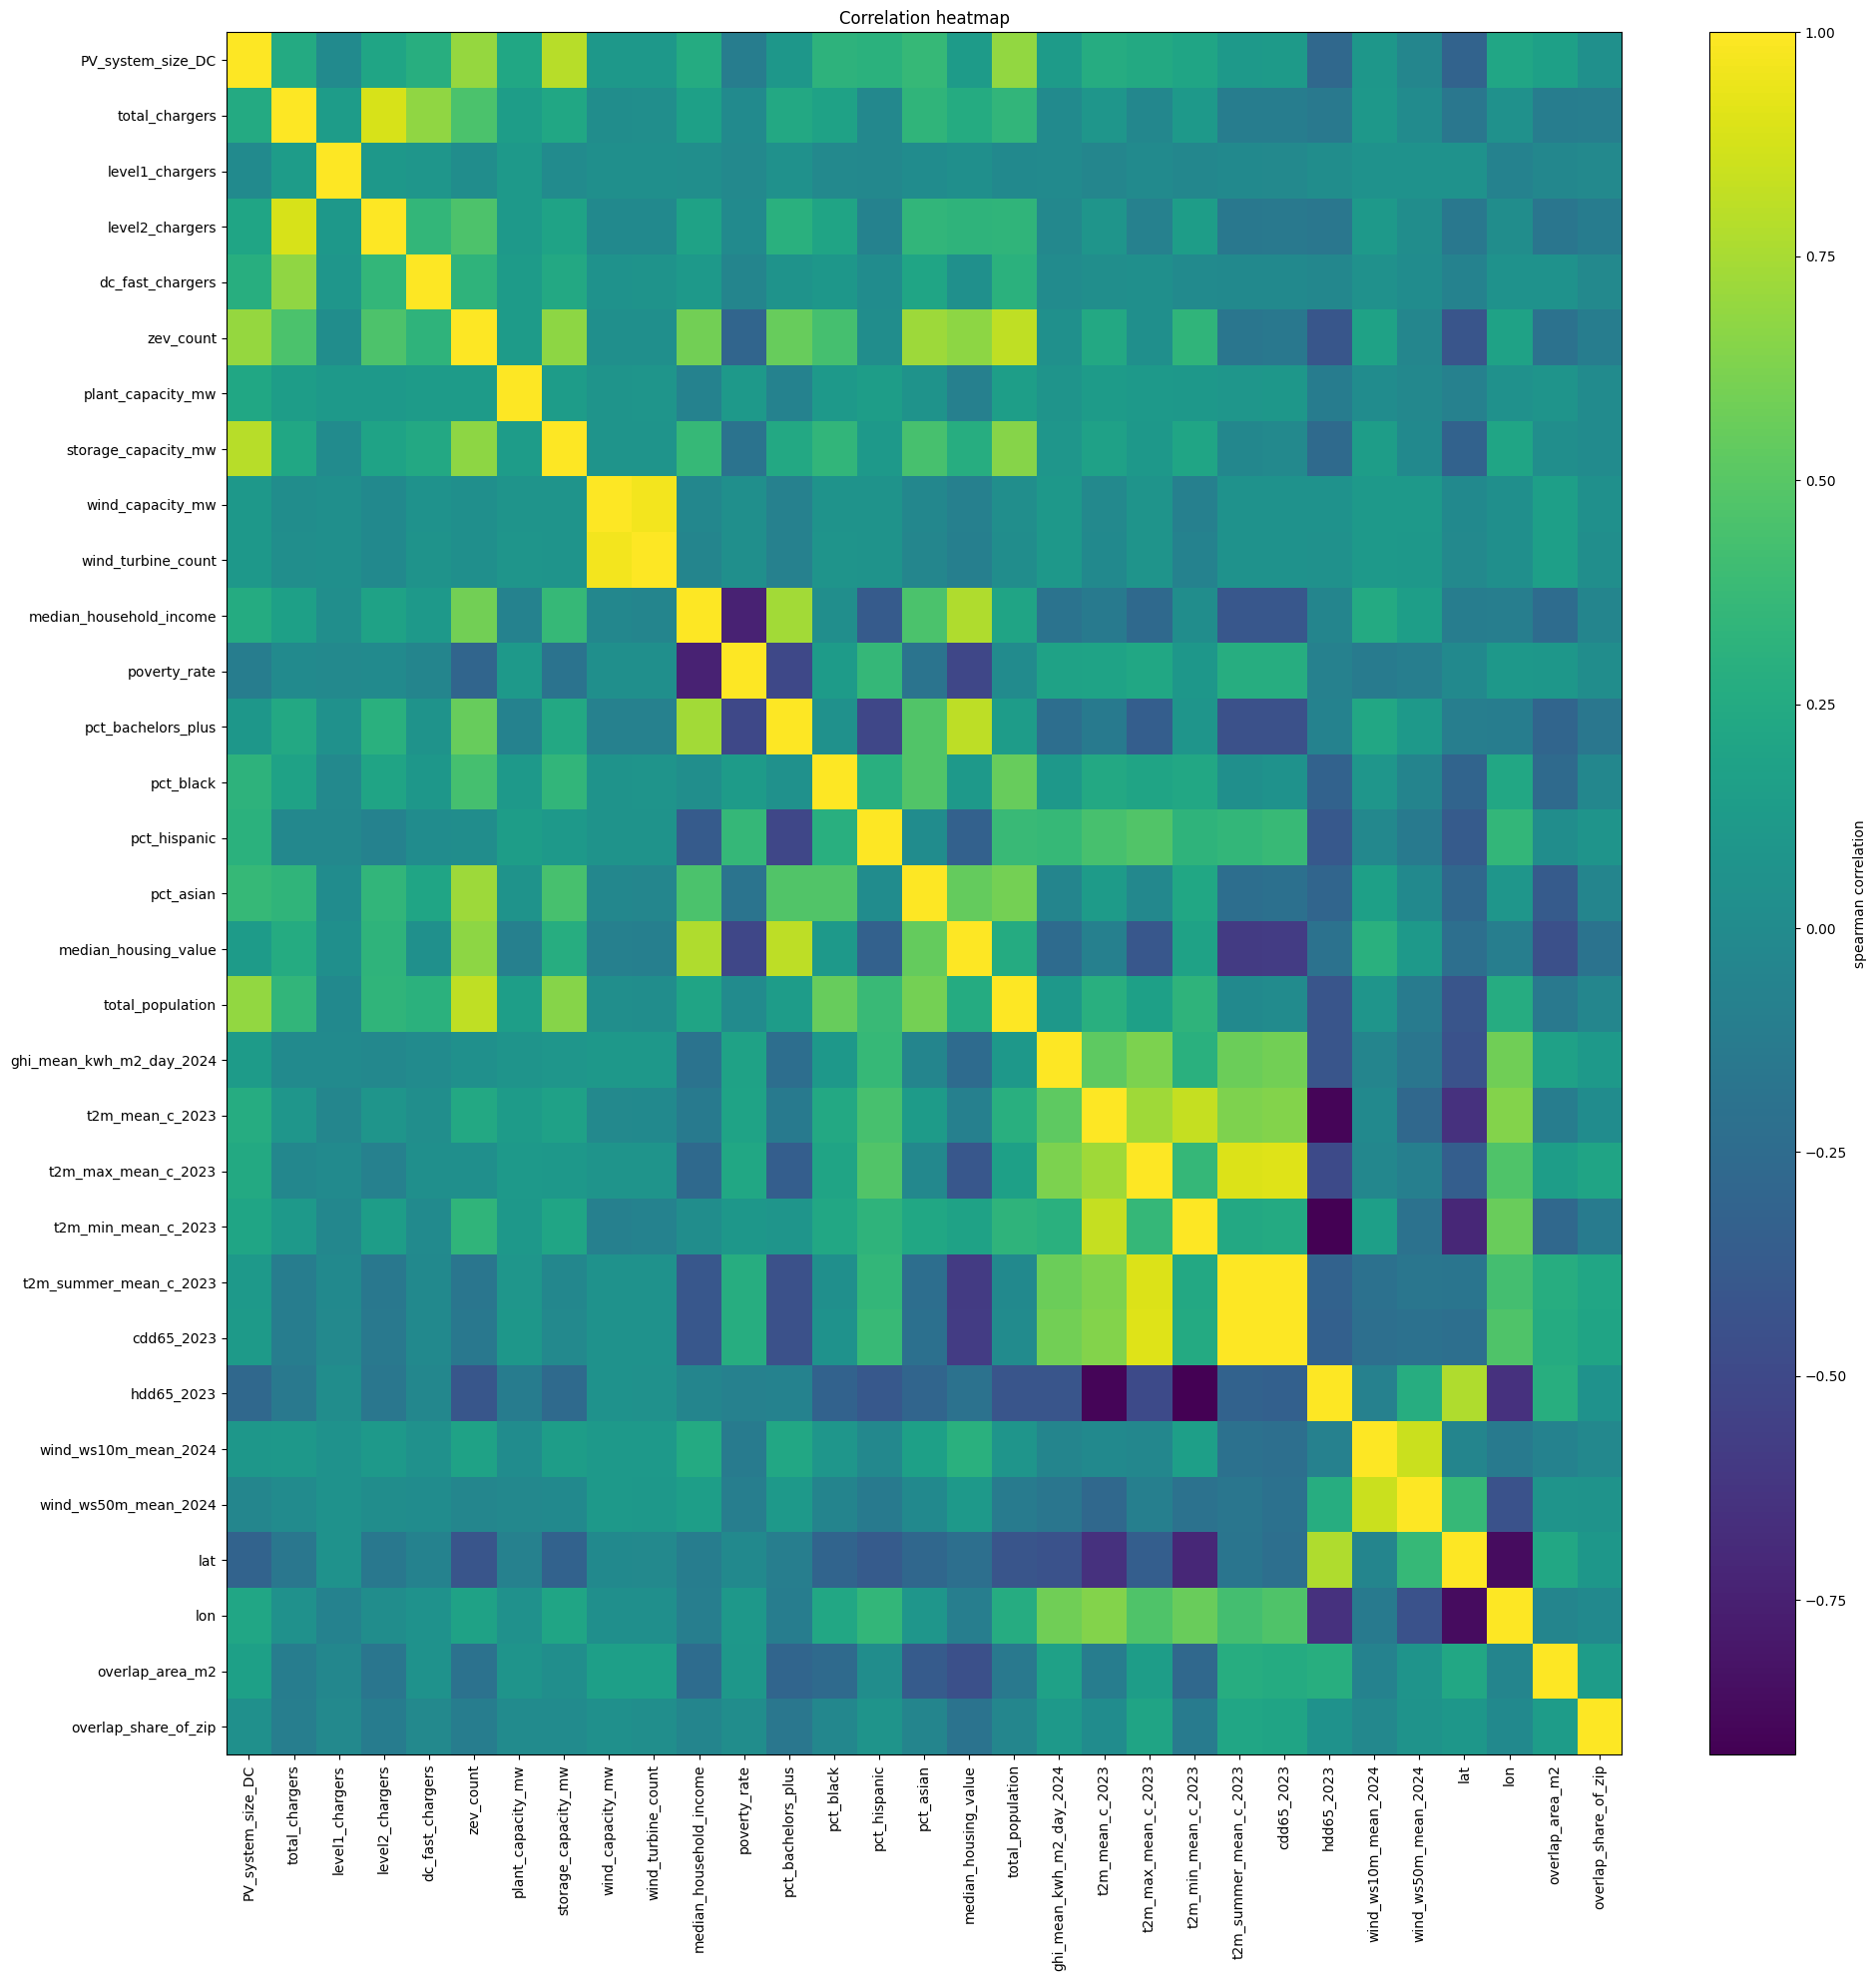

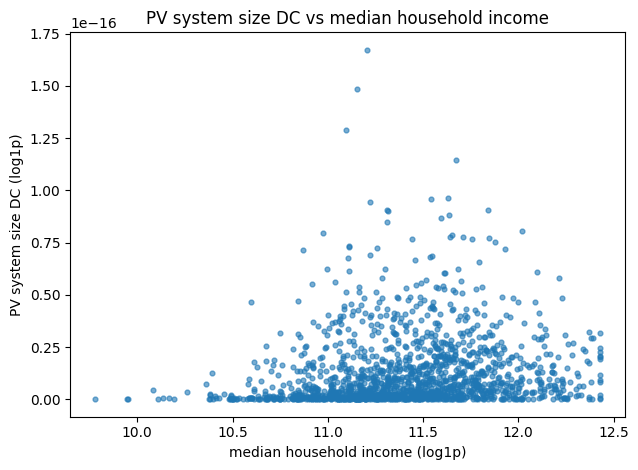

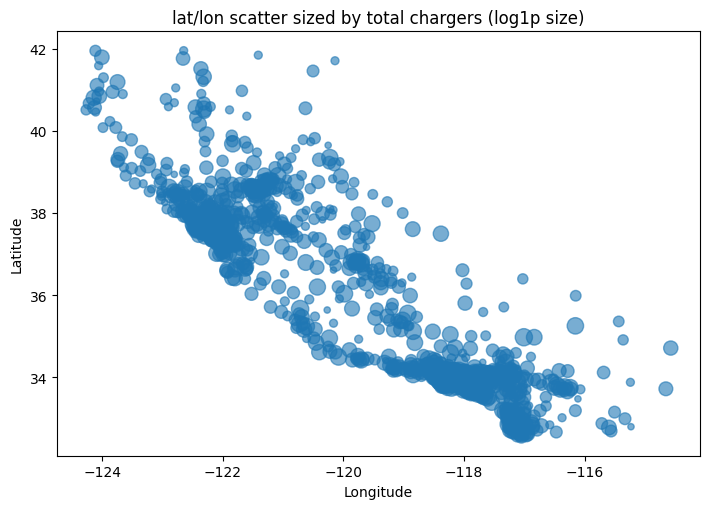

In [17]:
ZIP_SHAPEFILE = "../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp"
ZCTAS_CA = load_ca_zctas(ZIP_SHAPEFILE)
df = pd.read_csv(
    "../data/processed/combined_der_dataset_w_controls_predictors.csv"
)
df.drop(columns = ["Unnamed: 0"], inplace = True)
run_eda_overview(df, zctas_ca=ZCTAS_CA)

# Or run specific views:
plot_missingness(df)
plot_hist_grid(df)  # auto-picks numeric columns
plot_corr_heatmap(df, method="spearman")  # good when relationships are monotonic/nonlinear
scatter(df, "median_household_income", "PV_system_size_DC", log1p_x=True, log1p_y=True)
plot_geo_scatter(df, "total_chargers")

In [18]:
def agg_by_zip(df: pd.DataFrame, value_col: str, how: str = "sum") -> pd.DataFrame:
    d = df[["zip_code", value_col]].copy()
    d["zip_code"] = d["zip_code"].astype(str).str.zfill(5)

    if how == "count":
        out = d.groupby("zip_code").size().reset_index(name=value_col)
    else:
        out = d.groupby("zip_code")[value_col].agg(how).reset_index()

    return out

# Example: sum nameplate capacity by zip
print(df.columns)
df["zip_code"] = df["zip_code"].astype(str)
# Merge onto polygons (left join keeps all ZCTAs)
gdf_merged = ZCTAS_CA.merge(df, left_on="ZCTA5CE20", right_on="zip_code", how="left")
gdf_merged.to_csv(f'../data/processed/combined_der_dataset_w_shape.csv', index=True)

Index(['zip_code', 'PV_system_size_DC', 'total_chargers', 'level1_chargers',
       'level2_chargers', 'dc_fast_chargers', 'zev_count', 'plant_capacity_mw',
       'storage_capacity_mw', 'wind_capacity_mw', 'wind_turbine_count',
       'median_household_income', 'poverty_rate', 'pct_bachelors_plus',
       'pct_black', 'pct_hispanic', 'pct_asian', 'median_housing_value',
       'total_population', 'ghi_mean_kwh_m2_day_2024', 't2m_mean_c_2023',
       't2m_max_mean_c_2023', 't2m_min_mean_c_2023', 't2m_summer_mean_c_2023',
       'cdd65_2023', 'hdd65_2023', 'wind_ws10m_mean_2024',
       'wind_ws50m_mean_2024', 'lat', 'lon', 'acronym', 'utility',
       'utility_type', 'overlap_area_m2', 'overlap_share_of_zip'],
      dtype='object')
